# Problema del Agente Viajero (TSP)

## Modelo de Redes de Transporte y Simulación Logística

En esta práctica se resolverá un **Problema del Agente Viajero (Traveling Salesman Problem, TSP)** mediante diferentes estrategias computacionales.

Se utilizará el mismo problema desarrollado durante la clase: un vehículo parte de un Centro de Distribución (CEDIS), debe visitar seis clientes exactamente una vez y finalmente regresar al punto de origen.

Se analizarán los siguientes métodos:

1. Representación de la red con NetworkX.
2. Heurística del Vecino Más Cercano.
3. Mejora mediante 2-opt.
4. Comparación de las soluciones obtenidas.
## 1. Definición del problema

Una empresa de distribución cuenta con un **Centro de Distribución (CEDIS)** desde el cual debe realizar entregas a seis clientes: **A, B, C, D, E y F**.

La empresa dispone de un solo vehículo.

El vehículo debe:

- Salir del CEDIS.
- Visitar cada cliente exactamente una vez.
- Regresar al CEDIS.
- Minimizar la distancia total recorrida.

La matriz de distancias es simétrica, por lo que la distancia de A hacia B es igual a la distancia de B hacia A.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

## 2. Matriz de distancias

La información del problema se representa mediante una matriz de distancias.

Cada posición de la matriz representa la distancia entre dos nodos de la red.

In [2]:
nodos=["CEDIS","A","B","C","D","E","F"]
matriz_distancias=[
[0,12,18,15,24,30,20],
[12,0,10,17,22,28,16],
[18,10,0,14,16,24,20],
[15,17,14,0,12,18,15],
[24,22,16,12,0,10,13],
[30,28,24,18,10,0,11],
[20,16,20,15,13,11,0]
]


distancias=pd.DataFrame(matriz_distancias,index=nodos,columns=nodos)
distancias

,CEDIS,A,B,C,D,E,F
CEDIS,0,12,18,15,24,30,20
A,12,0,10,17,22,28,16
B,18,10,0,14,16,24,20
C,15,17,14,0,12,18,15
D,24,22,16,12,0,10,13
E,30,28,24,18,10,0,11
F,20,16,20,15,13,11,0


## 3. Construcción de la red

El problema puede representarse mediante un **grafo completo ponderado**.

- Cada nodo representa una ubicación.
- Cada arista representa una conexión posible.
- El peso de cada arista representa la distancia entre los nodos.

En un TSP completo se considera que es posible viajar entre cualquier par de ubicaciones.

In [3]:
G=nx.Graph()
for i in range(len(nodos)):
    for j in range(i+1,len(nodos)):
        G.add_edge(nodos[i],nodos[j],weight=matriz_distancias[i][j])
print("Nodos:",G.number_of_nodes())
print("Aristas:",G.number_of_edges())

Nodos: 7
Aristas: 21


## 4. Visualización de la red

La siguiente representación permite observar las conexiones existentes entre los nodos.

Debido a que se trata de un grafo completo, todos los nodos se encuentran conectados entre sí.

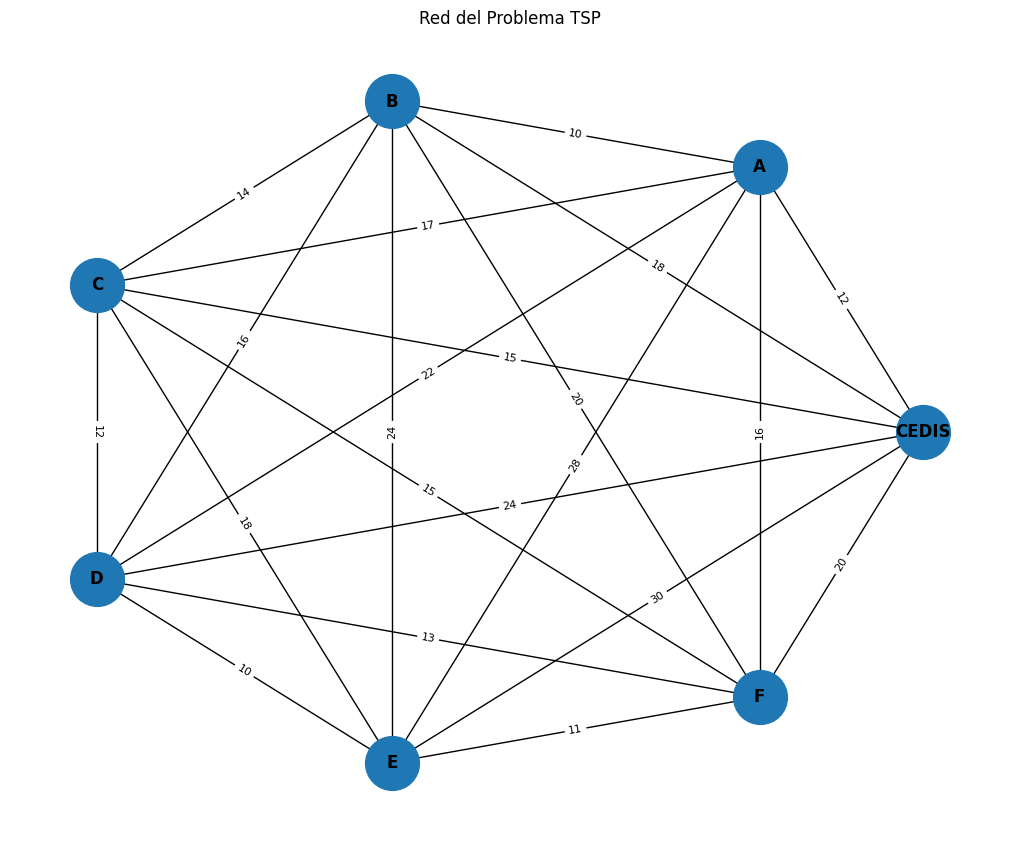

In [4]:
pos=nx.circular_layout(G)
plt.figure(figsize=(10,8))
nx.draw(G,pos,with_labels=True,node_size=1500,font_weight="bold")
labels=nx.get_edge_attributes(G,"weight")
nx.draw_networkx_edge_labels(G,pos,edge_labels=labels,font_size=8)
plt.title("Red del Problema TSP")
plt.show()

# 5. Heurística del Vecino Más Cercano

La heurística del **Vecino Más Cercano (Nearest Neighbor)** construye una solución siguiendo una regla sencilla:

1. Seleccionar el nodo inicial.
2. Buscar el nodo no visitado más cercano.
3. Viajar hacia ese nodo.
4. Repetir el procedimiento hasta visitar todos los nodos.
5. Regresar al nodo inicial.

Este método encuentra rápidamente una solución factible, pero **no garantiza que sea la solución óptima**.

In [5]:
def vecino_mas_cercano(matriz,nodos,inicio=0):
    visitados=[inicio]
    actual=inicio
    distancia_total=0
    while len(visitados)<len(nodos):
        candidatos=[i for i in range(len(nodos)) if i not in visitados]
        siguiente=min(candidatos,key=lambda i:matriz[actual][i])
        distancia_total+=matriz[actual][siguiente]
        visitados.append(siguiente)
        actual=siguiente
    distancia_total+=matriz[actual][inicio]
    visitados.append(inicio)
    ruta=[nodos[i] for i in visitados]
    return ruta,distancia_total

ruta_vecino,distancia_vecino=vecino_mas_cercano(matriz_distancias,nodos)
print("Ruta:", " → ".join(ruta_vecino))
print("Distancia total:",distancia_vecino,"km")

Ruta: CEDIS → A → B → C → D → E → F → CEDIS
Distancia total: 89 km


## Interpretación

La heurística comenzó en el CEDIS y seleccionó en cada iteración el cliente no visitado más cercano.

La ruta obtenida fue:

**CEDIS → A → B → C → D → E → F → CEDIS**

con una distancia total de:

**89 km**

Esta solución es factible porque visita todos los clientes exactamente una vez y regresa al CEDIS.

Sin embargo, todavía no podemos afirmar que sea la mejor ruta posible.

# 6. Heurística 2-opt

La heurística **2-opt** intenta mejorar una ruta existente mediante el intercambio de conexiones.

El procedimiento consiste en:

1. Partir de una solución inicial.
2. Seleccionar dos posiciones de la ruta.
3. Invertir el segmento comprendido entre ambas posiciones.
4. Calcular nuevamente la distancia.
5. Conservar el cambio si reduce el recorrido.
6. Repetir hasta que no se encuentren nuevas mejoras.

2-opt es una heurística de **búsqueda local**, ya que intenta mejorar una solución que ya existe.

In [6]:
def calcular_distancia(ruta,matriz,nodos):
    indices=[nodos.index(nodo) for nodo in ruta]
    return sum(matriz[indices[i]][indices[i+1]] for i in range(len(indices)-1))

def dos_opt(ruta,matriz,nodos):
    mejor_ruta=ruta[:]
    mejor_distancia=calcular_distancia(mejor_ruta,matriz,nodos)
    mejora=True
    while mejora:
        mejora=False
        for i in range(1,len(mejor_ruta)-2):
            for j in range(i+1,len(mejor_ruta)-1):
                nueva_ruta=mejor_ruta[:i]+mejor_ruta[i:j+1][::-1]+mejor_ruta[j+1:]
                nueva_distancia=calcular_distancia(nueva_ruta,matriz,nodos)
                if nueva_distancia<mejor_distancia:
                    mejor_ruta=nueva_ruta
                    mejor_distancia=nueva_distancia
                    mejora=True
    return mejor_ruta,mejor_distancia

ruta_2opt,distancia_2opt=dos_opt(ruta_vecino,matriz_distancias,nodos)
print("Ruta inicial:"," → ".join(ruta_vecino))
print("Distancia inicial:",distancia_vecino,"km")
print("\nRuta después de 2-opt:"," → ".join(ruta_2opt))
print("Distancia después de 2-opt:",distancia_2opt,"km")

Ruta inicial: CEDIS → A → B → C → D → E → F → CEDIS
Distancia inicial: 89 km

Ruta después de 2-opt: CEDIS → A → B → C → D → E → F → CEDIS
Distancia después de 2-opt: 89 km


# 7. Comparación de resultados

Ahora podemos comparar la solución obtenida mediante Vecino Más Cercano contra la solución mejorada mediante 2-opt.

La diferencia entre ambos métodos permite observar una característica importante de las heurísticas:

**una solución factible no necesariamente es una solución óptima.**

In [7]:
resultados=pd.DataFrame({"Método":["Vecino Más Cercano","2-opt"],"Distancia (km)":[distancia_vecino,distancia_2opt]})
resultados

mejora=((distancia_vecino-distancia_2opt)/distancia_vecino)*100
print(f"Mejora obtenida: {mejora:.2f}%")

Mejora obtenida: 0.00%


# 8. Visualización de la ruta obtenida

Además de calcular la distancia, podemos representar gráficamente únicamente las conexiones utilizadas por la solución.

Esto permite distinguir el recorrido seleccionado del grafo completo del problema.

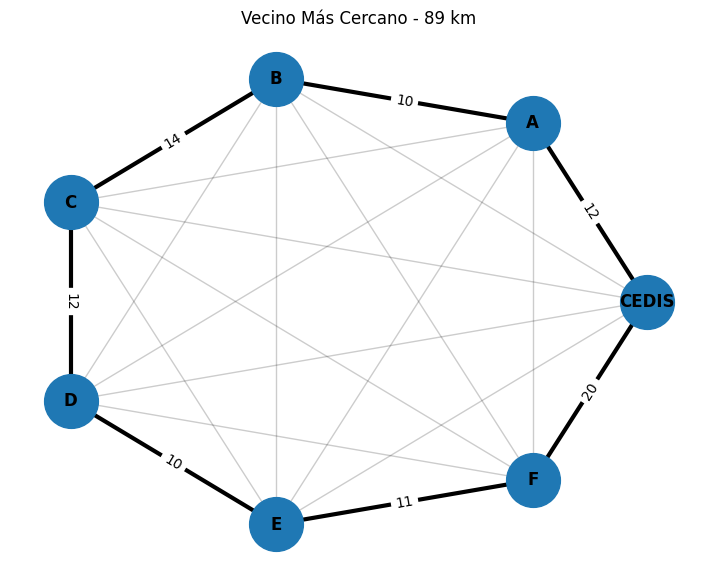

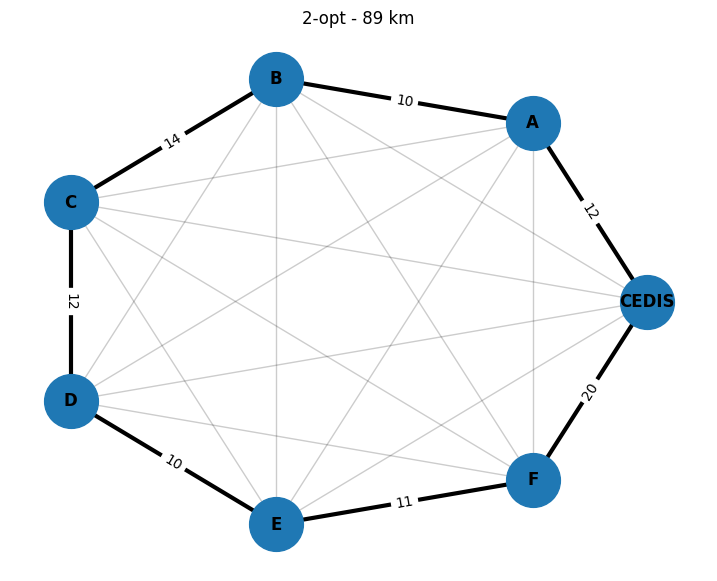

In [8]:
def visualizar_ruta(G,ruta,pos,titulo):
    plt.figure(figsize=(9,7))
    nx.draw_networkx_nodes(G,pos,node_size=1500)
    nx.draw_networkx_labels(G,pos,font_weight="bold")
    nx.draw_networkx_edges(G,pos,alpha=0.2)
    aristas_ruta=list(zip(ruta[:-1],ruta[1:]))
    nx.draw_networkx_edges(G,pos,edgelist=aristas_ruta,width=3)
    etiquetas={(u,v):G[u][v]["weight"] for u,v in aristas_ruta}
    nx.draw_networkx_edge_labels(G,pos,edge_labels=etiquetas)
    plt.title(titulo)
    plt.axis("off")
    plt.show()

visualizar_ruta(G,ruta_vecino,pos,f"Vecino Más Cercano - {distancia_vecino} km")
visualizar_ruta(G,ruta_2opt,pos,f"2-opt - {distancia_2opt} km")

# 9. ¿Podemos conocer la solución óptima?

Para una red pequeña podemos evaluar todas las combinaciones posibles.

Este procedimiento se conoce como **fuerza bruta**.

Si fijamos el CEDIS como punto inicial, se generan todas las permutaciones posibles de los seis clientes y se calcula la distancia de cada recorrido.

Este método permite encontrar la solución óptima, pero su costo computacional aumenta rápidamente conforme aumenta el número de clientes.

In [9]:
from itertools import permutations
def fuerza_bruta(matriz,nodos):
    clientes=nodos[1:]
    mejor_ruta=None
    mejor_distancia=float("inf")
    for permutacion in permutations(clientes):
        ruta=[nodos[0]]+list(permutacion)+[nodos[0]]
        distancia=calcular_distancia(ruta,matriz,nodos)
        if distancia<mejor_distancia:
            mejor_distancia=distancia
            mejor_ruta=ruta
    return mejor_ruta,mejor_distancia
ruta_optima,distancia_optima=fuerza_bruta(matriz_distancias,nodos)
print("Ruta óptima:"," → ".join(ruta_optima))
print("Distancia óptima:",distancia_optima,"km")

Ruta óptima: CEDIS → A → B → C → D → E → F → CEDIS
Distancia óptima: 89 km


# 10. Comparación final

Ahora podemos comparar:

- Vecino Más Cercano.
- 2-opt.
- Solución óptima mediante fuerza bruta.

Esto permite analizar qué tan cerca estuvieron las heurísticas de la solución óptima.

In [10]:
comparacion=pd.DataFrame({"Método":["Vecino Más Cercano","2-opt","Fuerza Bruta"],"Distancia (km)":[distancia_vecino,distancia_2opt,distancia_optima]})
comparacion

gap_vecino=((distancia_vecino-distancia_optima)/distancia_optima)*100
gap_2opt=((distancia_2opt-distancia_optima)/distancia_optima)*100
print(f"Gap Vecino Más Cercano: {gap_vecino:.2f}%")
print(f"Gap 2-opt: {gap_2opt:.2f}%")

Gap Vecino Más Cercano: 0.00%
Gap 2-opt: 0.00%


# Análisis

Responda las siguientes preguntas:

1. ¿Qué ruta encontró la heurística del Vecino Más Cercano?
2. ¿La heurística 2-opt logró mejorarla?
3. ¿Cuál fue la solución óptima?
4. ¿Qué diferencia existe entre la mejor heurística y la solución óptima?
5. ¿Por qué no sería conveniente utilizar fuerza bruta con 50 clientes?
6. ¿Qué ventajas tienen las heurísticas para problemas logísticos reales?
7. ¿Considera que siempre es necesario encontrar la solución matemáticamente óptima?

# Conclusiones

El Problema del Agente Viajero permite observar una diferencia importante entre los métodos exactos y las heurísticas.

Los métodos exactos permiten encontrar la solución óptima, pero su costo computacional puede aumentar considerablemente conforme crece el problema.

Las heurísticas, como Vecino Más Cercano y 2-opt, permiten encontrar soluciones de buena calidad en tiempos considerablemente menores.

En problemas logísticos reales, donde pueden existir cientos o miles de clientes, esta relación entre **calidad de la solución y tiempo de cómputo** se vuelve fundamental.